In [1]:
import geopandas as gpd
aoi = gpd.read_file("~/Data-to-Impact-Challenge/aoi_layer/NoVA_Boundaries.geojson")
aoi = aoi.to_crs(epsg=3857) # make meters instead of lat/long

In [ ]:
import numpy as np
from shapely.geometry import box

def make_square_grid(aoi, cell_size):
    minx, miny, maxx, maxy = aoi.total_bounds
    
    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)

    squares = []
    for x in xs:
        for y in ys:
            squares.append(box(x, y, x + cell_size, y + cell_size))

    grid = gpd.GeoDataFrame(geometry=squares, crs=aoi.crs)
    return grid

grid = make_square_grid(aoi, cell_size=2500) # in meters

grid = gpd.clip(grid, aoi)

In [6]:
ids = []
ids = [f"G{i:04d}" for i in range(0, 1010)]

grid["cell_id"] = ids # make grid ids
grid

,geometry,cell_id
775,"POLYGON ((-8636212.739 4670455.317, -8636212.7...",G0000
776,"POLYGON ((-8636212.739 4672955.317, -8636212.7...",G0001
777,"POLYGON ((-8638712.739 4675455.317, -8636212.7...",G0002
729,"POLYGON ((-8638712.739 4675455.317, -8638712.7...",G0003
778,"POLYGON ((-8638712.739 4675455.317, -8638712.7...",G0004
...,...,...
478,"POLYGON ((-8653712.739 4765455.317, -8653996.0...",G1005
622,"POLYGON ((-8646212.739 4765455.317, -8648712.7...",G1006
670,"POLYGON ((-8643712.739 4765455.317, -8646212.7...",G1007
623,"POLYGON ((-8647694.897 4767955.317, -8647487.9...",G1008


In [ ]:
grid = grid.to_crs(epsg=4326) # change from meters to long/lat
grid

,geometry,cell_id
775,"POLYGON ((-77.58042 38.64155, -77.58042 38.629...",G0000
776,"POLYGON ((-77.58042 38.65908, -77.58042 38.641...",G0001
777,"POLYGON ((-77.60288 38.67662, -77.58042 38.676...",G0002
729,"POLYGON ((-77.60288 38.67662, -77.60288 38.662...",G0003
778,"POLYGON ((-77.60288 38.67662, -77.60288 38.694...",G0004
...,...,...
478,"POLYGON ((-77.73762 39.305, -77.74017 39.305, ...",G1005
622,"POLYGON ((-77.67025 39.305, -77.69271 39.305, ...",G1006
670,"POLYGON ((-77.64779 39.305, -77.67025 39.305, ...",G1007
623,"POLYGON ((-77.68356 39.32238, -77.68171 39.323...",G1008


In [9]:
grid.to_file("~/Data-to-Impact-Challenge/tessa-grid/northern_va_grid.geojson", driver="GeoJSON")
grid.to_file("~/Data-to-Impact-Challenge/tessa-grid/northern_va_grid.shp")

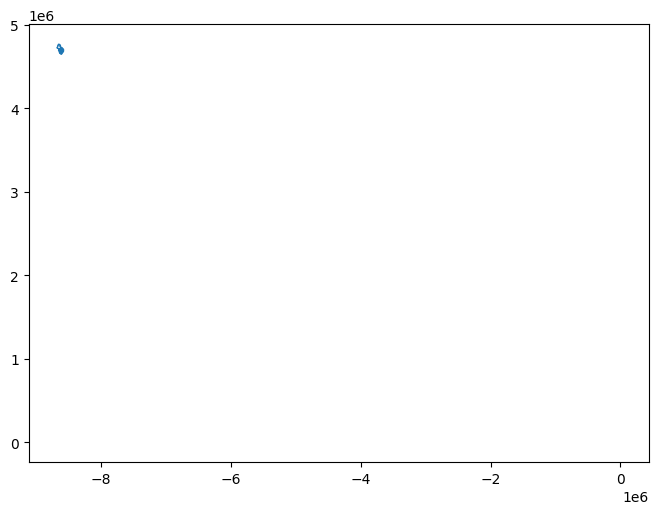

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
aoi.boundary.plot(ax=ax, linewidth=1)
grid.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.3)
plt.show()